<a href="https://colab.research.google.com/github/pano1215/Bigdata_analyst_certification-/blob/main/Colab_%EC%8B%9C%EC%9E%91%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# 1. 데이터 로드 및 간단한 전처리 (결측치 채우기)
df = pd.read_csv('/content/SBA_보증심사_강의용_15k.csv')

In [3]:

# 수치형 변수 결측치는 평균으로, 범주형은 최빈값으로 채웁니다.
df['Term'] = df['Term'].fillna(df['Term'].mean())
df['NoEmp'] = df['NoEmp'].fillna(df['NoEmp'].mean())
df['DisbursementGross'] = df['DisbursementGross'].fillna(df['DisbursementGross'].mean())
df['GuaranteeRatio'] = df['GuaranteeRatio'].fillna(df['GuaranteeRatio'].mean())

# 분석에 사용할 '대출 신청 시점'의 특징(Features)과 정답(Target) 정의
feature_cols = ['Term', 'NoEmp', 'DisbursementGross', 'GuaranteeRatio', 'UrbanRural', 'NewBusiness']
X = df[feature_cols]
y = df['Default']

# 학습용/테스트용 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 방법 ①: 상관관계 분석 (Correlation)
# ==========================================
corr_res = df[feature_cols + ['Default']].corr()['Default'].abs().sort_values(ascending=False).drop('Default')

# ==========================================
# 방법 ②: 로지스틱 회귀분석 (Logistic Regression)
# ==========================================
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_coef = pd.Series(np.abs(lr.coef_[0]), index=feature_cols).sort_values(ascending=False)

# ==========================================
# 방법 ③: 의사결정나무 (Decision Tree)
# ==========================================
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
dt_imp = pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False)

# ==========================================
# 방법 ④: 랜덤 포레스트 (Random Forest)
# ==========================================
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

# ==========================================
# 방법 ⑤: XGBoost
# ==========================================
xg_model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xg_model.fit(X_train, y_train)
xgb_imp = pd.Series(xg_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

# ==========================================
# 종합 결과 출력
# ==========================================
print("=== 5가지 방법론별 부도 영향력 탑랭커 리스트 ===")
print(f"\n1. 상관관계 기준 순위:\n{corr_res.index.tolist()}")
print(f"\n2. 로지스틱 회귀 기준 순위:\n{lr_coef.index.tolist()}")
print(f"\n3. 의사결정나무 기준 순위:\n{dt_imp.index.tolist()}")
print(f"\n4. 랜덤 포레스트 기준 순위:\n{rf_imp.index.tolist()}")
print(f"\n5. XGBoost 기준 순위:\n{xgb_imp.index.tolist()}")

=== 5가지 방법론별 부도 영향력 탑랭커 리스트 ===

1. 상관관계 기준 순위:
['Term', 'GuaranteeRatio', 'UrbanRural', 'DisbursementGross', 'NoEmp', 'NewBusiness']

2. 로지스틱 회귀 기준 순위:
['UrbanRural', 'GuaranteeRatio', 'NewBusiness', 'Term', 'NoEmp', 'DisbursementGross']

3. 의사결정나무 기준 순위:
['Term', 'UrbanRural', 'DisbursementGross', 'NewBusiness', 'NoEmp', 'GuaranteeRatio']

4. 랜덤 포레스트 기준 순위:
['Term', 'DisbursementGross', 'NoEmp', 'GuaranteeRatio', 'UrbanRural', 'NewBusiness']

5. XGBoost 기준 순위:
['Term', 'UrbanRural', 'GuaranteeRatio', 'DisbursementGross', 'NewBusiness', 'NoEmp']


/tmp/ipykernel_415/1430457953.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ratio_default.index, y=ratio_default.values, ax=axes[1], palette='Greens_r')
/tmp/ipykernel_415/1430457953.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=env_default.index, y=env_default.values, ax=axes[2], palette='spring')
/tmp/ipykernel_415/1430457953.py:68: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_415/1430457953.py:68: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_415/1430457953.py:68: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing

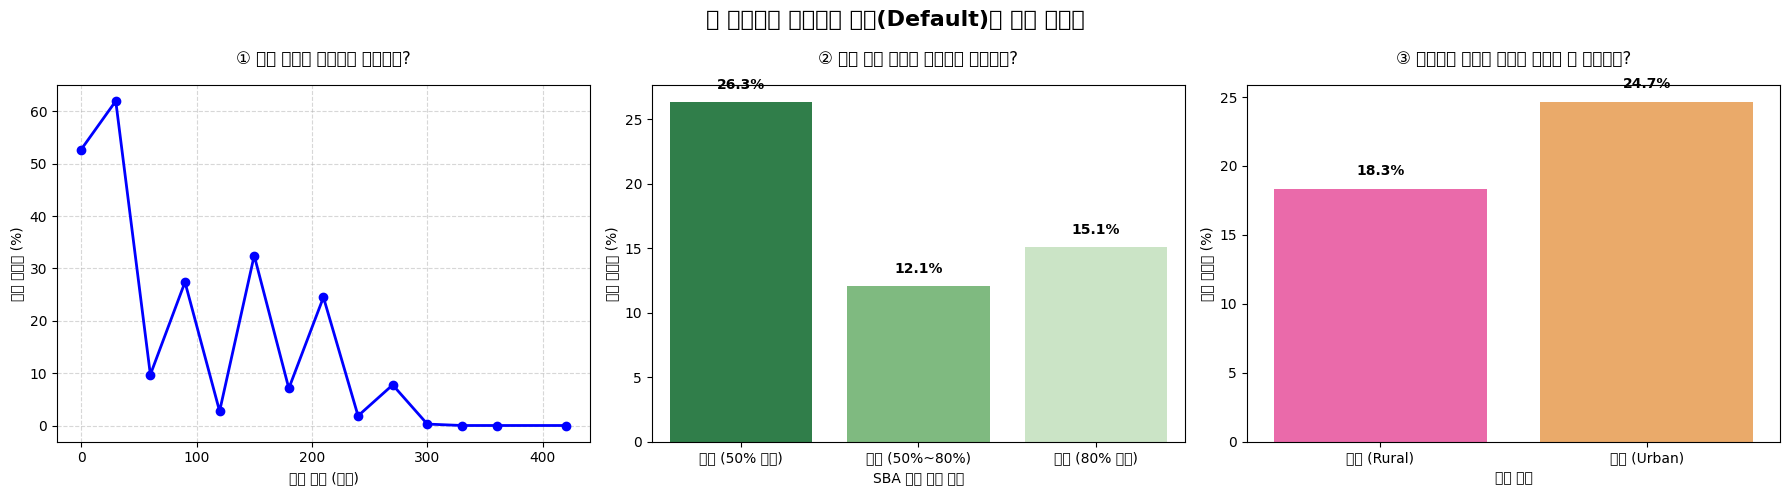

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 깨짐 방지 설정 (실행하는 환경이 윈도우라면 'Malgun Gothic'을 사용합니다)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2. 그림을 그릴 스케치북 만들기 (가로 18인치, 세로 5인치로 3개의 칸을 나눕니다)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🔍 데이터로 확인하는 부도(Default)의 진짜 원인들', fontsize=16, fontweight='bold')

# ----------------------------------------------------
# [그래프 1] 대출 기간(Term)과 부도율의 관계
# ----------------------------------------------------
# 대출 기간을 이해하기 쉽게 30개월(2.5년) 단위로 묶어서 그룹을 만듭니다.
df['Term_Group'] = (df['Term'] // 30) * 30
term_default = df.groupby('Term_Group')['Default'].mean() * 100

# 선 그래프 그리기
axes[0].plot(term_default.index, term_default.values, marker='o', color='blue', linewidth=2)
axes[0].set_title('① 대출 기간이 짧을수록 위험할까?', fontsize=12, pad=15)
axes[0].set_xlabel('대출 기간 (개월)', fontsize=10)
axes[0].set_ylabel('실제 부도율 (%)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5)

# ----------------------------------------------------
# [그래프 2] 보증 비율(GuaranteeRatio)과 부도율의 관계
# ----------------------------------------------------
# 보증 비율이 50% 이하, 50%~80%, 80% 이상인 경우로 쪼개어 봅니다.
def cat_ratio(x):
    if x <= 0.5: return '낮음 (50% 이하)'
    elif x <= 0.8: return '보통 (50%~80%)'
    else: return '높음 (80% 초과)'

df['Ratio_Group'] = df['GuaranteeRatio'].apply(cat_ratio)
ratio_default = df.groupby('Ratio_Group')['Default'].mean().reindex(['낮음 (50% 이하)', '보통 (50%~80%)', '높음 (80% 초과)']) * 100

# 막대 그래프 그리기 (초록색 계열)
sns.barplot(x=ratio_default.index, y=ratio_default.values, ax=axes[1], palette='Greens_r')
axes[1].set_title('② 정부 보증 비율이 낮을수록 위험할까?', fontsize=12, pad=15)
axes[1].set_xlabel('SBA 보증 비율 수준', fontsize=10)
axes[1].set_ylabel('실제 부도율 (%)', fontsize=10)

# 막대 위에 숫자(퍼센트) 적어주기
for i, v in enumerate(ratio_default.values):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

# ----------------------------------------------------
# [그래프 3] 거주 환경(UrbanRural)과 부도율의 관계
# ----------------------------------------------------
# 0은 미분류, 1은 도시, 2는 시골을 의미합니다.
env_map = {0: '미분류', 1: '도시 (Urban)', 2: '시골 (Rural)'}
df['Environment'] = df['UrbanRural'].map(env_map)
env_default = df.groupby('Environment')['Default'].mean().reindex(['시골 (Rural)', '도시 (Urban)']) * 100

# 막대 그래프 그리기 (노란색/분홍색 계열)
sns.barplot(x=env_default.index, y=env_default.values, ax=axes[2], palette='spring')
axes[2].set_title('③ 시골보다 경쟁이 치열한 도시가 더 위험할까?', fontsize=12, pad=15)
axes[2].set_xlabel('지역 구분', fontsize=10)
axes[2].set_ylabel('실제 부도율 (%)', fontsize=10)

# 막대 위에 숫자(퍼센트) 적어주기
for i, v in enumerate(env_default.values):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

# 레이아웃 예쁘게 다듬기
plt.tight_layout()
plt.show()